# A small diffusion model
If we want to work on series generations with a diffusion model, we will need to gather a large dataset and compose a large model.

However, in this lab, we will build a tiny diffusion model on the MNIST dataset.

Recommend to change your Runtime to GPU.

In [2]:
!pip install -q torchvision

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional
import torch.optim as optim
from torchvision import datasets, transforms # for image related datasets, just like torch-geometric for graphs
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 1. Downloading dataset
We will download the MNIST dataset from torchvision.

We transform the images into a 14x14 pixel matrix.

In [ ]:
pic_dim = (14, 14)
transform = transforms.Compose([
    transforms.Resize(pic_dim),   # downsample MNIST
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x*2-1)  # scale [-1,1] for diffusion
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.82MB/s]


#### Next, we load the dataset to DataLoader, which automatically divides the data into batches.

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

### Let's have a look at the dataset

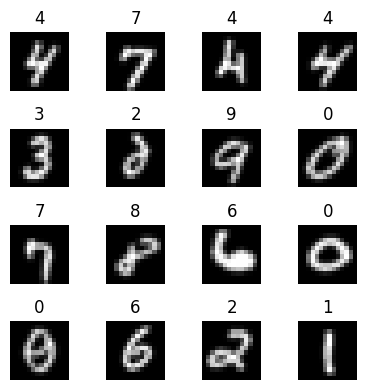

In [ ]:
# get one batch
x, y = next(iter(train_loader))

# rescale from [-1,1] → [0,1] for display
x = (x + 1) / 2

fig, axs = plt.subplots(4, 4, figsize=(4,4))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(x[i][0], cmap='gray')
    ax.set_title(int(y[i]))
    ax.axis('off')

plt.tight_layout()

## 2. Define a simple Diffusion Network

In [ ]:
class SimpleDiff(nn.Module):
    '''
    A diffusion model.
    '''
    def __init__(self, data_size, hidden_size=128):
        '''
        Args:
            data_size: the size of the input data
            hidden_size: the size of the hidden layer
        '''
        super().__init__()
        self.fc1 = nn.Linear(data_size+1, hidden_size) # +1: time step t
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, data_size)

    def forward(self, x, t):
        # shapes: x: [batch, 14*14], t: [batch, 1]
        x_in = torch.cat([x, t], dim=1) # stack x and t together
        h = functional.relu(self.fc1(x_in))
        h = functional.relu(self.fc2(h))
        out = self.fc3(h)
        return out

### Define the diffusion hyperparameters

In [ ]:
T = 50  # diffusion steps
beta = torch.linspace(0.0001, 0.02, T).to(device)  # linear schedule, noise gets bigger with time steps
alpha = 1 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

In [ ]:
# forward process is closed form
def forward_xt(x0, t):
    """get x_t in the forward process"""
    noise = torch.randn_like(x0).to(device)
    a_bar = alpha_bar[t].view(-1,1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise, noise

### Define training settings

In [ ]:
data_size = pic_dim[0] * pic_dim[1]


model = SimpleDiff(data_size=data_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

loss_func = nn.MSELoss()

## 3. Start Training

In [ ]:
epochs = 10  # short to save time

for epoch in range(epochs):
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device) # turn into a vectors
        t = torch.randint(0, T, (x.size(0),), device=device) # randomly choose a set of time steps to train on
        x_noisy, noise = forward_xt(x, t) # evaluate x_t and noise

        t_norm = t.float() / T # renormalize t to turn them into numbers between [0, 1]
        t_norm = t_norm.unsqueeze(1)

        noise_pred = model(x_noisy, t_norm) # predict the noise
        loss = loss_func(noise_pred, noise) # the noise should match the forward noise

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    # if (epoch+1) % 1 == 0 or epoch==0:


Epoch 1, Loss: 0.7337
Epoch 2, Loss: 0.6841
Epoch 3, Loss: 0.6421
Epoch 4, Loss: 0.6307
Epoch 5, Loss: 0.5924
Epoch 6, Loss: 0.6233
Epoch 7, Loss: 0.6132
Epoch 8, Loss: 0.6112
Epoch 9, Loss: 0.5671
Epoch 10, Loss: 0.6129


## 4. Generation

In [ ]:
model.eval()
with torch.no_grad():
    z = torch.randn(16, data_size, device=device) # sample 16 random states
    for t in reversed(range(T)):
        t_norm = torch.full((z.size(0),1), t/T, device=device)
        eps = model(z, t_norm)
        a = alpha[t]
        a_bar_prev = alpha_bar[t-1] if t > 0 else torch.tensor(1.0, device=device)
        x = (1/torch.sqrt(a)) * (z - ((1-a)/torch.sqrt(1-alpha_bar[t]))*eps) # mu
        if t > 0:
            x += torch.sqrt(beta[t]) * torch.randn_like(x) # add noise Sigma

    x = (x + 1) / 2  # rescale to [0,1]
    x = x.view(-1, 1, pic_dim[0], pic_dim[1]).cpu() # turn vector back to matrix

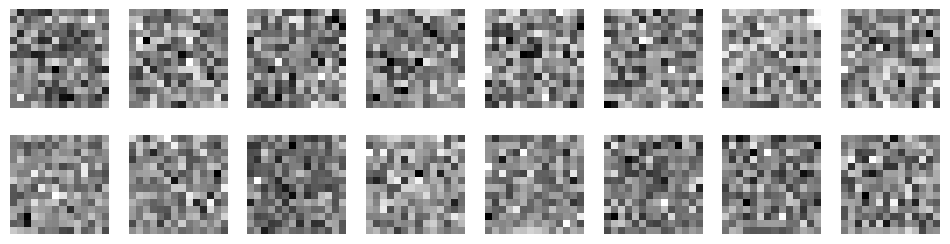

In [ ]:
fig, axs = plt.subplots(2,8, figsize=(12,3))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(x[i,0], cmap='gray')
    ax.axis('off')
plt.show()